# AI-Driven Healthcare Analytics and Patient Risk Assessment


# Introduction

The healthcare industry generates vast amounts of patient data every day, creating valuable opportunities for data-driven decision-making and predictive analytics. Analyzing this data helps healthcare organizations understand patient demographics, disease patterns, healthcare utilization, medical costs, and treatment outcomes, ultimately improving the quality and efficiency of healthcare services.

This project focuses on analyzing a synthetic healthcare dataset generated using Synthea, an open-source patient simulator that creates realistic electronic health records (EHRs) while preserving patient privacy. The dataset includes information on patients, healthcare encounters, medical conditions, medications, healthcare expenses, and insurance coverage.

The project applies data preprocessing, exploratory data analysis (EDA), statistical analysis, and interactive Plotly visualizations to identify meaningful patterns and trends within the dataset. In addition, a machine learning model is developed to demonstrate how Artificial Intelligence (AI) can be used for patient risk assessment and predictive healthcare analytics. The overall objective is to transform healthcare data into meaningful insights that support informed healthcare decision-making.

# Dataset Description

This project uses a synthetic healthcare dataset generated using Synthea, an open-source patient simulator that creates realistic electronic health records (EHRs). The dataset is divided into four related tables:

Patients: Contains demographic details, healthcare expenses, insurance coverage, and patient information.

Encounters: Contains hospital visits, encounter types, providers, and healthcare costs.

Conditions: Contains patient diagnoses and medical condition history.

Medications: Contains prescribed medications, medication costs, and insurance coverage.

# Important Features Used

The analysis primarily focuses on the following variables:

Age

Gender

Race

Healthcare Expenses

Healthcare Coverage

Medical Conditions

Medication Cost

Encounter Type

Visit Year

Risk Level (derived)

In [ ]:
# 1. Data Loading and Initial Overview
# Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from plotly.subplots import make_subplots
import plotly.graph_objects as go
# Load Required Datasets
patients = pd.read_csv('patients.csv')
encounters = pd.read_csv('encounters.csv')
conditions = pd.read_csv('conditions.csv')
medications = pd.read_csv('medications.csv')
# Number of Rows and Columns
print("Patients:", patients.shape)
print("Encounters:", encounters.shape)
print("Conditions:", conditions.shape)
print("Medications:", medications.shape)

The datasets were loaded successfully.The shape function was used to determine the number of rows and columns in each dataset.


In [103]:
patients.info()
encounters.info()
conditions.info()
medications.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1163 entries, 0 to 1162
Data columns (total 25 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   Id                   1163 non-null   object 
 1   BIRTHDATE            1163 non-null   object 
 2   DEATHDATE            163 non-null    object 
 3   SSN                  1163 non-null   object 
 4   DRIVERS              948 non-null    object 
 5   PASSPORT             887 non-null    object 
 6   PREFIX               918 non-null    object 
 7   FIRST                1163 non-null   object 
 8   LAST                 1163 non-null   object 
 9   SUFFIX               16 non-null     object 
 10  MAIDEN               331 non-null    object 
 11  MARITAL              779 non-null    object 
 12  RACE                 1163 non-null   object 
 13  ETHNICITY            1163 non-null   object 
 14  GENDER               1163 non-null   object 
 15  BIRTHPLACE           1163 non-null   o

The info() function provides information about column names, data types, and non-null values.

In [104]:
# First Five Records
patients.head()

,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,LAST,SUFFIX,MAIDEN,MARITAL,RACE,ETHNICITY,GENDER,BIRTHPLACE,ADDRESS,CITY,STATE,COUNTY,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE
0,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,2019-02-17,NaN,999-65-3251,NaN,NaN,NaN,Damon455,Langosh790,NaN,NaN,NaN,white,nonhispanic,M,Middleborough Massachusetts US,620 Lynch Tunnel Apt 0,Springfield,Massachusetts,Hampden County,1104.0,42.080389,-72.480431,9039.1645,7964.1255
1,c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8,2005-07-04,NaN,999-49-3323,S99941126,NaN,NaN,Thi53,Wunsch504,NaN,NaN,NaN,white,nonhispanic,F,Danvers Massachusetts US,972 Tillman Branch Suite 48,Bellingham,Massachusetts,Norfolk County,NaN,42.035213,-71.482519,402723.4150,14064.1350
2,339144f8-50e1-633e-a013-f361391c4cff,1998-05-11,NaN,999-10-8743,S99996708,X75063318X,Mr.,Chi716,Greenfelder433,NaN,NaN,NaN,white,nonhispanic,M,Athens Athens Prefecture GR,1060 Bernhard Crossroad Suite 15,Boston,Massachusetts,Suffolk County,2131.0,42.292557,-71.061160,571935.8725,787.5375
3,d488232e-bf14-4bed-08c0-a82f34b6a197,2003-01-28,NaN,999-56-6057,S99929424,NaN,Ms.,Phillis443,Walter473,NaN,NaN,NaN,white,nonhispanic,F,Boston Massachusetts US,677 Ritchie Terrace,Hingham,Massachusetts,Plymouth County,2043.0,42.200491,-70.916076,582557.8030,104782.2070
4,217f95a3-4e10-bd5d-fb67-0cfb5e8ba075,1993-12-23,NaN,999-91-4320,S99991143,X44132498X,Mr.,Jerrold404,Herzog843,NaN,NaN,M,black,nonhispanic,M,Boston Massachusetts US,276 Bernier Branch,Revere,Massachusetts,Suffolk County,NaN,42.381875,-70.999286,475826.8550,18067.0950


In [105]:
encounters.head()

,Id,START,STOP,PATIENT,ORGANIZATION,PROVIDER,PAYER,ENCOUNTERCLASS,CODE,DESCRIPTION,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE,REASONDESCRIPTION
0,748f8357-6cc7-551d-f31a-32fa2cf84126,2019-02-17T05:07:38Z,2019-02-17T05:22:38Z,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,f7ae497d-8dc6-3721-9402-43b621a4e7d2,82608ebb-037c-3cef-9d34-3736d69b29e8,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,wellness,410620009,Well child visit (procedure),129.16,877.79,833.90,NaN,NaN
1,5a4735ae-423f-6563-28ab-b3d11b49b2d4,2019-03-24T05:07:38Z,2019-03-24T05:22:38Z,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,f7ae497d-8dc6-3721-9402-43b621a4e7d2,82608ebb-037c-3cef-9d34-3736d69b29e8,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,wellness,410620009,Well child visit (procedure),129.16,269.68,256.20,NaN,NaN
2,0bee1ce6-3e2c-5506-f71c-a7ba8f64a3d3,2019-05-26T05:07:38Z,2019-05-26T05:22:38Z,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,f7ae497d-8dc6-3721-9402-43b621a4e7d2,82608ebb-037c-3cef-9d34-3736d69b29e8,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,wellness,410620009,Well child visit (procedure),129.16,1292.75,1228.11,NaN,NaN
3,6e93bcf9-45a4-8528-0120-1c1eaa930faf,2019-07-28T05:07:38Z,2019-07-28T05:22:38Z,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,f7ae497d-8dc6-3721-9402-43b621a4e7d2,82608ebb-037c-3cef-9d34-3736d69b29e8,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,wellness,410620009,Well child visit (procedure),129.16,1323.87,1257.68,NaN,NaN
4,8b6787c3-4316-a0cb-899d-4746525c319f,2019-10-27T05:07:38Z,2019-10-27T05:22:38Z,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,f7ae497d-8dc6-3721-9402-43b621a4e7d2,82608ebb-037c-3cef-9d34-3736d69b29e8,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,wellness,410620009,Well child visit (procedure),129.16,831.76,790.17,NaN,NaN


In [106]:
conditions.head()

,START,STOP,PATIENT,ENCOUNTER,CODE,DESCRIPTION
0,2013-06-24,2013-07-02,c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8,0b2794bd-ec2b-d34f-0610-2523b3b7fcf0,10509002,Acute bronchitis (disorder)
1,2016-02-27,2016-03-14,c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8,a6d818dd-0983-fd1c-eefa-3d2295532c45,283371005,Laceration of forearm
2,2016-08-11,2016-08-22,c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8,36d2e781-4655-0a11-1f70-c69856e02019,444814009,Viral sinusitis (disorder)
3,2016-11-27,2016-12-17,c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8,c8eaaf41-958b-31ab-7de5-568cee8751f3,444814009,Viral sinusitis (disorder)
4,2017-02-22,2017-06-02,c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8,6474f606-5a1b-48c0-bbbf-ad6dcbc24d4e,16114001,Fracture of ankle


In [107]:
medications.head()

,START,STOP,PATIENT,PAYER,ENCOUNTER,CODE,DESCRIPTION,BASE_COST,PAYER_COVERAGE,DISPENSES,TOTALCOST,REASONCODE,REASONDESCRIPTION
0,2020-02-17T10:40:32Z,NaN,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,01efcc52-15d6-51e9-faa2-bee069fcbe44,1014676,cetirizine hydrochloride 5 MG Oral Tablet,21.45,0.0,21,450.45,NaN,NaN
1,2020-02-17T10:40:32Z,NaN,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,01efcc52-15d6-51e9-faa2-bee069fcbe44,1870230,NDA020800 0.3 ML Epinephrine 1 MG/ML Auto-Inje...,231.58,0.0,21,4863.18,NaN,NaN
2,2013-06-24T06:39:19Z,2013-07-02T06:39:19Z,c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8,42c4fca7-f8a9-3cd1-982a-dd9751bf3e2a,0b2794bd-ec2b-d34f-0610-2523b3b7fcf0,1043400,Acetaminophen 21.7 MG/ML / Dextromethorphan Hy...,7.59,0.0,1,7.59,10509002.0,Acute bronchitis (disorder)
3,2016-02-27T08:52:29Z,2016-03-14T08:52:29Z,c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8,6e2f1a2d-27bd-3701-8d08-dae202c58632,a6d818dd-0983-fd1c-eefa-3d2295532c45,198405,Ibuprofen 100 MG Oral Tablet,12.48,0.0,1,12.48,NaN,NaN
4,2017-02-22T09:25:31Z,2017-06-02T09:25:31Z,c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8,047f6ec3-6215-35eb-9608-f9dda363a44c,6474f606-5a1b-48c0-bbbf-ad6dcbc24d4e,313820,Acetaminophen 160 MG Chewable Tablet,4.77,0.0,3,14.31,NaN,NaN


The head() function displays the first five records and helps understand the structure of the data.

In [108]:
# Statistical Summary
patients.describe()

,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE
count,618.000000,1163.000000,1163.000000,1.163000e+03,1.163000e+03
mean,2001.263754,42.255261,-71.336063,1.256248e+06,1.717684e+05
std,443.449141,0.286969,0.618013,1.148747e+06,4.885749e+05
min,1001.000000,41.299942,-73.445165,8.259920e+02,0.000000e+00
25%,1835.000000,42.100121,-71.516412,4.426256e+05,1.293600e+03
50%,2118.500000,42.307061,-71.140665,1.142154e+06,1.747219e+04
75%,2190.000000,42.448367,-71.004105,1.900910e+06,2.051068e+05
max,2861.000000,42.888532,-69.978831,2.311655e+07,1.356228e+07


In [109]:
encounters.describe()

,CODE,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,REASONCODE
count,6.145900e+04,61459.000000,61459.000000,61459.000000,1.595700e+04
mean,2.652707e+08,113.262767,4149.657952,1033.709602,4.860573e+12
std,1.575171e+08,23.847374,10919.677889,4902.646135,2.123179e+14
min,1.505002e+06,77.490000,0.000000,0.000000,1.734006e+06
25%,1.626730e+08,77.490000,129.160000,0.000000,5.582200e+07
50%,1.853470e+08,129.160000,786.330000,0.000000,7.289200e+07
75%,3.909060e+08,129.160000,1625.890000,29.990000,1.956620e+08
max,7.029270e+08,129.160000,873646.190000,227851.810000,1.093988e+16


In [110]:
conditions['DESCRIPTION'].value_counts().head(10)
# This gives most common diseases.

DESCRIPTION
Full-time employment (finding)                13805
Stress (finding)                               5137
Part-time employment (finding)                 2426
Social isolation (finding)                     1243
Viral sinusitis (disorder)                     1233
Limited social contact (finding)               1200
Not in labor force (finding)                   1077
Victim of intimate partner abuse (finding)      819
Acute viral pharyngitis (disorder)              678
Acute bronchitis (disorder)                     571
Name: count, dtype: int64

In [111]:
medications['DESCRIPTION'].value_counts().head(10)
# This shows the most prescribed medications


DESCRIPTION
lisinopril 10 MG Oral Tablet                                                                            8166
Hydrochlorothiazide 25 MG Oral Tablet                                                                   7509
amLODIPine 2.5 MG Oral Tablet                                                                           5942
insulin human  isophane 70 UNT/ML / Regular Insulin  Human 30 UNT/ML Injectable Suspension [Humulin]    4068
24 HR Metformin hydrochloride 500 MG Extended Release Oral Tablet                                       2996
Simvastatin 10 MG Oral Tablet                                                                           2489
NDA020503 200 ACTUAT Albuterol 0.09 MG/ACTUAT Metered Dose Inhaler                                      2341
120 ACTUAT Fluticasone propionate 0.044 MG/ACTUAT Metered Dose Inhaler                                  2337
Nitroglycerin 0.4 MG/ACTUAT Mucosal Spray                                                               1635
Simvast

The describe() function provides summary statistics including count, mean, minimum, maximum, and quartiles. For conditions.csv and medications.csv most columns are text values instead of using describe() used value_count() function

In [112]:
# 2. Data Pre-processing
patients.isnull().sum()

Id                        0
BIRTHDATE                 0
DEATHDATE              1000
SSN                       0
DRIVERS                 215
PASSPORT                276
PREFIX                  245
FIRST                     0
LAST                      0
SUFFIX                 1147
MAIDEN                  832
MARITAL                 384
RACE                      0
ETHNICITY                 0
GENDER                    0
BIRTHPLACE                0
ADDRESS                   0
CITY                      0
STATE                     0
COUNTY                    0
ZIP                     545
LAT                       0
LON                       0
HEALTHCARE_EXPENSES       0
HEALTHCARE_COVERAGE       0
dtype: int64

In [113]:
encounters.isnull().sum()

Id                         0
START                      0
STOP                       0
PATIENT                    0
ORGANIZATION               0
PROVIDER                   0
PAYER                      0
ENCOUNTERCLASS             0
CODE                       0
DESCRIPTION                0
BASE_ENCOUNTER_COST        0
TOTAL_CLAIM_COST           0
PAYER_COVERAGE             0
REASONCODE             45502
REASONDESCRIPTION      45502
dtype: int64

In [114]:
conditions.isnull().sum()

START             0
STOP           8169
PATIENT           0
ENCOUNTER         0
CODE              0
DESCRIPTION       0
dtype: int64

In [115]:
medications.isnull().sum()

START                    0
STOP                  2713
PATIENT                  0
PAYER                    0
ENCOUNTER                0
CODE                     0
DESCRIPTION              0
BASE_COST                0
PAYER_COVERAGE           0
DISPENSES                0
TOTALCOST                0
REASONCODE           15471
REASONDESCRIPTION    15471
dtype: int64

Missing value analysis was performed to identify incomplete records in the datasets.

In [116]:
# Handle Missing Values
missing_values = patients.isnull().sum()
print(missing_values)

Id                        0
BIRTHDATE                 0
DEATHDATE              1000
SSN                       0
DRIVERS                 215
PASSPORT                276
PREFIX                  245
FIRST                     0
LAST                      0
SUFFIX                 1147
MAIDEN                  832
MARITAL                 384
RACE                      0
ETHNICITY                 0
GENDER                    0
BIRTHPLACE                0
ADDRESS                   0
CITY                      0
STATE                     0
COUNTY                    0
ZIP                     545
LAT                       0
LON                       0
HEALTHCARE_EXPENSES       0
HEALTHCARE_COVERAGE       0
dtype: int64


In [117]:
missing_percent = (
    patients.isnull().sum() /
    len(patients)
) * 100

missing_summary = pd.DataFrame({
    'Missing Values': patients.isnull().sum(),
    'Percentage': missing_percent
})

print(missing_summary.sort_values(by='Percentage', ascending=False))

                     Missing Values  Percentage
SUFFIX                         1147   98.624248
DEATHDATE                      1000   85.984523
MAIDEN                          832   71.539123
ZIP                             545   46.861565
MARITAL                         384   33.018057
PASSPORT                        276   23.731728
PREFIX                          245   21.066208
DRIVERS                         215   18.486672
Id                                0    0.000000
ADDRESS                           0    0.000000
HEALTHCARE_EXPENSES               0    0.000000
LON                               0    0.000000
LAT                               0    0.000000
COUNTY                            0    0.000000
STATE                             0    0.000000
CITY                              0    0.000000
RACE                              0    0.000000
BIRTHPLACE                        0    0.000000
GENDER                            0    0.000000
ETHNICITY                         0    0

In [119]:
# Analyze Each Column
patients['DRIVERS'].fillna('Not Available', inplace=True)


In [122]:
patients['PASSPORT'].fillna('Not Available', inplace=True)

In [123]:
patients['PREFIX'].fillna('Unknown', inplace=True)

In [20]:
patients.drop(columns=['SUFFIX'], inplace=True)

In [124]:
patients.drop(columns=['MAIDEN'], inplace=True)

In [127]:
patients['MARITAL'].fillna('Unknown', inplace=True)

In [128]:
patients['ZIP'].fillna('Not Available', inplace=True)

In [129]:
patients.isnull().sum()

Id                        0
BIRTHDATE                 0
DEATHDATE              1000
SSN                       0
DRIVERS                   0
PASSPORT                  0
PREFIX                    0
FIRST                     0
LAST                      0
SUFFIX                 1147
MARITAL                   0
RACE                      0
ETHNICITY                 0
GENDER                    0
BIRTHPLACE                0
ADDRESS                   0
CITY                      0
STATE                     0
COUNTY                    0
ZIP                       0
LAT                       0
LON                       0
HEALTHCARE_EXPENSES       0
HEALTHCARE_COVERAGE       0
dtype: int64

Missing value analysis identified null values in several columns. 
The DEATHDATE column was retained because missing values indicate living patients. 
Columns with limited analytical significance and very high missing percentages (SUFFIX and MAIDEN) were removed. 
Missing categorical values in DRIVERS, PASSPORT, MARITAL, PREFIX, and ZIP were replaced 
with meaningful labels such as 'Unknown' or 'Not Available'.

In [130]:
# Analyze encounters column
encounters['REASONDESCRIPTION'] = encounters['REASONDESCRIPTION'].fillna('Not Specified')

In [131]:
encounters['REASONCODE'] = encounters['REASONCODE'].fillna('Not Specified')

In [132]:
encounters.isnull().sum()

Id                     0
START                  0
STOP                   0
PATIENT                0
ORGANIZATION           0
PROVIDER               0
PAYER                  0
ENCOUNTERCLASS         0
CODE                   0
DESCRIPTION            0
BASE_ENCOUNTER_COST    0
TOTAL_CLAIM_COST       0
PAYER_COVERAGE         0
REASONCODE             0
REASONDESCRIPTION      0
dtype: int64

The encounters dataset contained missing values in REASONCODE and REASONDESCRIPTION. These missing values represent encounters where a specific medical reason was not recorded. To facilitate analysis, missing values were replaced with the category "Not Specified".

In [133]:
# Analyze conditions column
# Creating derived columns
conditions['Condition_Status'] = np.where(
    conditions['STOP'].isna(),
    'Active',
    'Resolved'
)

In [134]:
conditions.head(30)

,START,STOP,PATIENT,ENCOUNTER,CODE,DESCRIPTION,Condition_Status
0,2013-06-24,2013-07-02,c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8,0b2794bd-ec2b-d34f-0610-2523b3b7fcf0,10509002,Acute bronchitis (disorder),Resolved
1,2016-02-27,2016-03-14,c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8,a6d818dd-0983-fd1c-eefa-3d2295532c45,283371005,Laceration of forearm,Resolved
2,2016-08-11,2016-08-22,c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8,36d2e781-4655-0a11-1f70-c69856e02019,444814009,Viral sinusitis (disorder),Resolved
3,2016-11-27,2016-12-17,c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8,c8eaaf41-958b-31ab-7de5-568cee8751f3,444814009,Viral sinusitis (disorder),Resolved
4,2017-02-22,2017-06-02,c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8,6474f606-5a1b-48c0-bbbf-ad6dcbc24d4e,16114001,Fracture of ankle,Resolved
5,2020-02-06,2020-03-14,c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8,a6da4c61-bc91-17a7-14a2-fda9023536a3,44465007,Sprain of ankle,Resolved
6,2012-06-11,2013-06-17,339144f8-50e1-633e-a013-f361391c4cff,33782d5d-ba30-c2e5-c432-e36a8f6c1cc8,160968000,Risk activity involvement (finding),Resolved
7,2012-08-07,2012-09-02,339144f8-50e1-633e-a013-f361391c4cff,4224e87e-d63e-4b30-a01b-03daffac9d26,44465007,Sprain of ankle,Resolved
8,2015-06-29,NaN,339144f8-50e1-633e-a013-f361391c4cff,28f73bd9-73d3-de33-35a6-cabeb9a5795c,162864005,Body mass index 30+ - obesity (finding),Active
9,2016-07-04,NaN,339144f8-50e1-633e-a013-f361391c4cff,8195411f-4a65-9245-07d3-1999e1c223df,59621000,Hypertension,Active


In [135]:
conditions['Condition_Status'].value_counts()

Condition_Status
Resolved    29925
Active       8169
Name: count, dtype: int64

In [136]:
conditions.isnull().sum()


START                  0
STOP                8169
PATIENT                0
ENCOUNTER              0
CODE                   0
DESCRIPTION            0
Condition_Status       0
dtype: int64

The STOP column contained 8,169 missing values. These missing values were not treated as errors because they indicate ongoing medical conditions. A new feature named Condition_Status was created to classify conditions as Active or Resolved.

In [137]:
# Analyze medications column
# Creating derived columns
medications['Medication_Status'] =np.where(
     medications['STOP'].isna(),
    'Active',
    'Completed'
)

In [138]:
medications['REASONCODE'] = medications['REASONCODE'].fillna('Not Specified')

In [139]:
medications['REASONDESCRIPTION'] = medications['REASONDESCRIPTION'].fillna('Not Specified')

In [140]:
medications.isnull().sum()

START                   0
STOP                 2713
PATIENT                 0
PAYER                   0
ENCOUNTER               0
CODE                    0
DESCRIPTION             0
BASE_COST               0
PAYER_COVERAGE          0
DISPENSES               0
TOTALCOST               0
REASONCODE              0
REASONDESCRIPTION       0
Medication_Status       0
dtype: int64

The medications dataset contained missing values in STOP, REASONCODE, and REASONDESCRIPTION. Missing STOP values were interpreted as ongoing medications and retained. A new feature called Medication_Status was created to classify medications as Active or Completed. Missing values in REASONCODE and REASONDESCRIPTION were replaced with "Not Specified" to facilitate analysis.

In [141]:
# Check Duplicate Records
patients.duplicated().sum()

np.int64(0)

In [142]:
encounters.duplicated().sum()

np.int64(0)

In [143]:
conditions.duplicated().sum()

np.int64(0)

In [144]:
medications.duplicated().sum()

np.int64(0)

Duplicate record analysis was performed on all datasets using the duplicated() function. No duplicate records were identified,therefore, no duplicate removal was required.

In [145]:
# Correcting data types
# 1. Check Current Data Types
patients.dtypes

Id                      object
BIRTHDATE               object
DEATHDATE               object
SSN                     object
DRIVERS                 object
PASSPORT                object
PREFIX                  object
FIRST                   object
LAST                    object
SUFFIX                  object
MARITAL                 object
RACE                    object
ETHNICITY               object
GENDER                  object
BIRTHPLACE              object
ADDRESS                 object
CITY                    object
STATE                   object
COUNTY                  object
ZIP                     object
LAT                    float64
LON                    float64
HEALTHCARE_EXPENSES    float64
HEALTHCARE_COVERAGE    float64
dtype: object

In [146]:
encounters.dtypes

Id                      object
START                   object
STOP                    object
PATIENT                 object
ORGANIZATION            object
PROVIDER                object
PAYER                   object
ENCOUNTERCLASS          object
CODE                     int64
DESCRIPTION             object
BASE_ENCOUNTER_COST    float64
TOTAL_CLAIM_COST       float64
PAYER_COVERAGE         float64
REASONCODE              object
REASONDESCRIPTION       object
dtype: object

In [147]:
conditions.dtypes

START               object
STOP                object
PATIENT             object
ENCOUNTER           object
CODE                 int64
DESCRIPTION         object
Condition_Status    object
dtype: object

In [148]:
medications.dtypes

START                 object
STOP                  object
PATIENT               object
PAYER                 object
ENCOUNTER             object
CODE                   int64
DESCRIPTION           object
BASE_COST            float64
PAYER_COVERAGE       float64
DISPENSES              int64
TOTALCOST            float64
REASONCODE            object
REASONDESCRIPTION     object
Medication_Status     object
dtype: object

In [149]:
# 2. Date Columns convertion
patients['BIRTHDATE'] = pd.to_datetime(patients['BIRTHDATE'])
patients['DEATHDATE'] = pd.to_datetime(patients['DEATHDATE'])
patients.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1163 entries, 0 to 1162
Data columns (total 24 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Id                   1163 non-null   object        
 1   BIRTHDATE            1163 non-null   datetime64[ns]
 2   DEATHDATE            163 non-null    datetime64[ns]
 3   SSN                  1163 non-null   object        
 4   DRIVERS              1163 non-null   object        
 5   PASSPORT             1163 non-null   object        
 6   PREFIX               1163 non-null   object        
 7   FIRST                1163 non-null   object        
 8   LAST                 1163 non-null   object        
 9   SUFFIX               16 non-null     object        
 10  MARITAL              1163 non-null   object        
 11  RACE                 1163 non-null   object        
 12  ETHNICITY            1163 non-null   object        
 13  GENDER               1163 non-nul

In [150]:
encounters['START'] = pd.to_datetime(encounters['START'])
encounters['STOP'] = pd.to_datetime(encounters['STOP'])
encounters.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61459 entries, 0 to 61458
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype              
---  ------               --------------  -----              
 0   Id                   61459 non-null  object             
 1   START                61459 non-null  datetime64[ns, UTC]
 2   STOP                 61459 non-null  datetime64[ns, UTC]
 3   PATIENT              61459 non-null  object             
 4   ORGANIZATION         61459 non-null  object             
 5   PROVIDER             61459 non-null  object             
 6   PAYER                61459 non-null  object             
 7   ENCOUNTERCLASS       61459 non-null  object             
 8   CODE                 61459 non-null  int64              
 9   DESCRIPTION          61459 non-null  object             
 10  BASE_ENCOUNTER_COST  61459 non-null  float64            
 11  TOTAL_CLAIM_COST     61459 non-null  float64            
 12  PAYER_COVERAGE    

In [151]:
conditions['START'] = pd.to_datetime(conditions['START'])
conditions['STOP'] = pd.to_datetime(conditions['STOP'])
conditions.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 38094 entries, 0 to 38093
Data columns (total 7 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   START             38094 non-null  datetime64[ns]
 1   STOP              29925 non-null  datetime64[ns]
 2   PATIENT           38094 non-null  object        
 3   ENCOUNTER         38094 non-null  object        
 4   CODE              38094 non-null  int64         
 5   DESCRIPTION       38094 non-null  object        
 6   Condition_Status  38094 non-null  object        
dtypes: datetime64[ns](2), int64(1), object(4)
memory usage: 2.0+ MB


In [152]:
medications['START'] = pd.to_datetime(medications['START'])
medications['STOP'] = pd.to_datetime(medications['STOP'])
medications.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 56430 entries, 0 to 56429
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype              
---  ------             --------------  -----              
 0   START              56430 non-null  datetime64[ns, UTC]
 1   STOP               53717 non-null  datetime64[ns, UTC]
 2   PATIENT            56430 non-null  object             
 3   PAYER              56430 non-null  object             
 4   ENCOUNTER          56430 non-null  object             
 5   CODE               56430 non-null  int64              
 6   DESCRIPTION        56430 non-null  object             
 7   BASE_COST          56430 non-null  float64            
 8   PAYER_COVERAGE     56430 non-null  float64            
 9   DISPENSES          56430 non-null  int64              
 10  TOTALCOST          56430 non-null  float64            
 11  REASONCODE         56430 non-null  object             
 12  REASONDESCRIPTION  56430 non-null  object     

Data type analysis was performed using the info() and dtypes functions. Date-related columns such as BIRTHDATE, DEATHDATE, START, and STOP were converted from object type to datetime format to support time-based analysis. Other columns were already stored in appropriate formats and required no further correction.

In [153]:
# Creating derived columns
# 1. Age
patients['Age'] = 2026 - patients['BIRTHDATE'].dt.year
# 2. Age Group
patients['Age_Group'] = pd.cut(
    patients['Age'],
    bins=[0,18,35,50,65,100],
    labels=['Child','Young Adult','Adult','Middle Age','Senior']
)
patients[['Age','Age_Group']].head(10)

,Age,Age_Group
0,7,Child
1,21,Young Adult
2,28,Young Adult
3,23,Young Adult
4,33,Young Adult
5,6,Child
6,36,Adult
7,41,Adult
8,47,Adult
9,20,Young Adult


In [154]:
# 3. Visit Year
encounters['Visit_Year'] = encounters['START'].dt.year
# 4. Visit Month
encounters['Visit_Month'] = encounters['START'].dt.month_name()
encounters[['Visit_Year','Visit_Month']].head(10)

,Visit_Year,Visit_Month
0,2019,February
1,2019,March
2,2019,May
3,2019,July
4,2019,October
5,2020,January
6,2020,February
7,2020,February
8,2020,April
9,2020,July


A new feature called Age was created from the patient's birth date. This enables age-based analysis, demographic profiling, and healthcare expense comparisons across different age groups.

The Age_Group column was derived from the Age feature to categorize patients into meaningful age ranges. This simplifies demographic analysis and helps identify healthcare trends across different life stages.

The Visit_Year feature was extracted from the encounter start date to support yearly trend analysis and identify changes in healthcare utilization over time.

The Visit_Month feature was derived from the encounter start date to facilitate monthly trend analysis and identify seasonal patterns in patient visits.

A new feature named Condition_Status was already created to classify conditions as Active or Resolved 
A new feature called Medication_Status was already created to classify medications as Active or Completed.


In [155]:
# Filtering
# Senior Patients (Age > 60)
senior_patients = patients[patients['Age'] > 60]
senior_patients.head()

,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,LAST,SUFFIX,MARITAL,RACE,ETHNICITY,GENDER,BIRTHPLACE,ADDRESS,CITY,STATE,COUNTY,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,Age,Age_Group
14,55a6a46e-a1a4-0298-e58f-c0cb27cbb022,1958-09-18,2009-11-13,999-79-5115,S99956983,X26820988X,Mrs.,Maddie576,Gutmann970,NaN,M,white,nonhispanic,F,Boston Massachusetts US,577 Schmeler Frontage road Unit 7,Quincy,Massachusetts,Norfolk County,2169.0,42.314702,-71.027005,2.895618e+06,312276.3060,68,Senior
17,1d3d0ba6-5475-07c2-0b40-562ad75fdf26,1960-01-21,NaT,999-26-4708,S99981133,X33683613X,Mrs.,Laurena366,Heidenreich818,NaN,M,white,nonhispanic,F,Lawrence Massachusetts US,1039 Gerhold Ramp Apt 20,East Longmeadow,Massachusetts,Hampden County,Not Available,42.087687,-72.526567,7.743821e+05,247928.6130,66,Senior
20,8c2d5e9b-0717-9616-beb9-21296a5b547d,1960-12-15,NaT,999-50-8690,S99926520,X57197008X,Ms.,Zelda766,Ernser583,NaN,S,white,nonhispanic,F,Amherst Massachusetts US,874 Skiles Club,Haverhill,Massachusetts,Essex County,1830.0,42.775897,-71.006616,2.341031e+06,177213.0915,66,Senior
21,a7624ac9-6308-e015-1c5c-115c97c631fe,1959-11-02,NaT,999-16-7928,S99982440,X77033125X,Mrs.,Esther279,Runolfsson901,NaN,M,white,nonhispanic,F,Billerica Massachusetts US,389 Mraz Pathway Apt 38,Waltham,Massachusetts,Middlesex County,2453.0,42.399832,-71.206038,2.286987e+06,480203.1860,67,Senior
23,33c2ca32-ae38-66c5-474f-83273568906e,1955-10-25,NaT,999-85-9194,S99955746,X89300658X,Mr.,Franklyn361,Tromp100,NaN,M,white,hispanic,M,Westford Massachusetts US,394 Weissnat Meadow,Georgetown,Massachusetts,Essex County,Not Available,42.767251,-71.024799,1.860938e+06,52453.7150,71,Senior


Patients aged above 60 years were filtered to analyze healthcare trends among senior citizens.

In [156]:
# Female Patients
female_patients = patients[patients['GENDER'] == 'F']
pd.set_option('display.max_columns', None)
female_patients.head()

,Id,BIRTHDATE,DEATHDATE,SSN,DRIVERS,PASSPORT,PREFIX,FIRST,LAST,SUFFIX,MARITAL,RACE,ETHNICITY,GENDER,BIRTHPLACE,ADDRESS,CITY,STATE,COUNTY,ZIP,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,Age,Age_Group
1,c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8,2005-07-04,NaT,999-49-3323,S99941126,Not Available,Unknown,Thi53,Wunsch504,NaN,Unknown,white,nonhispanic,F,Danvers Massachusetts US,972 Tillman Branch Suite 48,Bellingham,Massachusetts,Norfolk County,Not Available,42.035213,-71.482519,4.027234e+05,14064.1350,21,Young Adult
3,d488232e-bf14-4bed-08c0-a82f34b6a197,2003-01-28,NaT,999-56-6057,S99929424,Not Available,Ms.,Phillis443,Walter473,NaN,Unknown,white,nonhispanic,F,Boston Massachusetts US,677 Ritchie Terrace,Hingham,Massachusetts,Plymouth County,2043.0,42.200491,-70.916076,5.825578e+05,104782.2070,23,Young Adult
5,faac724a-a9e9-be66-fe1e-3044dc0ba8ea,2020-12-04,NaT,999-31-8261,Not Available,Not Available,Unknown,Brandon214,Watsica258,NaN,Unknown,white,nonhispanic,F,Northborough Massachusetts US,734 Brakus Pathway Unit 28,New Marlborough,Massachusetts,Berkshire County,Not Available,42.147028,-73.217103,3.146804e+04,206.2200,6,Child
8,0288c42c-43a1-9878-4a9d-6b96caa12c40,1979-12-17,NaT,999-68-7908,S99962050,X4451825X,Mrs.,Miki234,Kozey370,NaN,M,white,nonhispanic,F,Northbridge Massachusetts US,636 Stamm Gateway,Cambridge,Massachusetts,Middlesex County,2472.0,42.337425,-71.106655,1.134818e+06,226909.9595,47,Adult
10,61a2fcc0-d679-764c-7d86-b885b2c4907f,1993-01-22,NaT,999-98-2186,S99988392,X72124702X,Mrs.,Erline657,Metz686,NaN,M,white,nonhispanic,F,Mashpee Massachusetts US,566 Rosenbaum Ferry,Holbrook,Massachusetts,Norfolk County,Not Available,42.151880,-70.952308,1.223458e+06,160.1400,33,Young Adult


Female patient records were filtered to support gender-based analysis.

In [157]:
# Active Conditions
active_conditions = conditions[conditions['Condition_Status'] == 'Active']
active_conditions.head()

,START,STOP,PATIENT,ENCOUNTER,CODE,DESCRIPTION,Condition_Status
8,2015-06-29,NaT,339144f8-50e1-633e-a013-f361391c4cff,28f73bd9-73d3-de33-35a6-cabeb9a5795c,162864005,Body mass index 30+ - obesity (finding),Active
9,2016-07-04,NaT,339144f8-50e1-633e-a013-f361391c4cff,8195411f-4a65-9245-07d3-1999e1c223df,59621000,Hypertension,Active
10,2016-07-04,NaT,339144f8-50e1-633e-a013-f361391c4cff,8195411f-4a65-9245-07d3-1999e1c223df,105531004,Housing unsatisfactory (finding),Active
11,2016-07-04,NaT,339144f8-50e1-633e-a013-f361391c4cff,8195411f-4a65-9245-07d3-1999e1c223df,5251000175109,Received certificate of high school equivalenc...,Active
20,2019-07-22,NaT,339144f8-50e1-633e-a013-f361391c4cff,69a236c7-3823-88d6-5791-17e9d66fdb98,423315002,Limited social contact (finding),Active


Active medical conditions were filtered to identify ongoing health issues among patients.

In [158]:
# Active Medications
active_medications = medications[medications['Medication_Status'] == 'Active']
active_medications.head()

,START,STOP,PATIENT,PAYER,ENCOUNTER,CODE,DESCRIPTION,BASE_COST,PAYER_COVERAGE,DISPENSES,TOTALCOST,REASONCODE,REASONDESCRIPTION,Medication_Status
0,2020-02-17 10:40:32+00:00,NaT,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,01efcc52-15d6-51e9-faa2-bee069fcbe44,1014676,cetirizine hydrochloride 5 MG Oral Tablet,21.45,0.0,21,450.45,Not Specified,Not Specified,Active
1,2020-02-17 10:40:32+00:00,NaT,b9c610cd-28a6-4636-ccb6-c7a0d2a4cb85,7c4411ce-02f1-39b5-b9ec-dfbea9ad3c1a,01efcc52-15d6-51e9-faa2-bee069fcbe44,1870230,NDA020800 0.3 ML Epinephrine 1 MG/ML Auto-Inje...,231.58,0.0,21,4863.18,Not Specified,Not Specified,Active
6,2021-06-23 08:20:52+00:00,NaT,c1f1fcaa-82fd-d5b7-3544-c8f9708b06a8,047f6ec3-6215-35eb-9608-f9dda363a44c,68e737e5-a4a1-0ffd-7234-8fb04a2b0c19,1000126,1 ML medroxyPROGESTERone acetate 150 MG/ML Inj...,227.63,0.0,5,1138.15,Not Specified,Not Specified,Active
26,2021-08-02 05:03:31+00:00,NaT,339144f8-50e1-633e-a013-f361391c4cff,047f6ec3-6215-35eb-9608-f9dda363a44c,fbf1824f-1ef7-820f-111b-6982ef9a9e5f,310798,Hydrochlorothiazide 25 MG Oral Tablet,0.01,0.0,3,0.03,59621000.0,Hypertension,Active
27,2021-08-02 05:03:31+00:00,NaT,339144f8-50e1-633e-a013-f361391c4cff,047f6ec3-6215-35eb-9608-f9dda363a44c,fbf1824f-1ef7-820f-111b-6982ef9a9e5f,314076,lisinopril 10 MG Oral Tablet,0.02,0.0,112,2.24,59621000.0,Hypertension,Active


Active medications were filtered to examine ongoing treatment patterns.

In [159]:
# Aggregation
# Average Healthcare Expenses by Gender
patients.groupby('GENDER')['HEALTHCARE_EXPENSES'].mean()


GENDER
F    1.389849e+06
M    1.105795e+06
Name: HEALTHCARE_EXPENSES, dtype: float64

Average healthcare expenses were calculated for each gender to compare spending patterns.

In [160]:
# Average Healthcare Expenses by Race
patients.groupby('RACE')['HEALTHCARE_EXPENSES'].mean()

RACE
asian       1.160193e+06
black       1.572326e+06
hawaiian    1.199746e+06
native      7.076682e+05
other       8.098974e+05
white       1.239315e+06
Name: HEALTHCARE_EXPENSES, dtype: float64

Healthcare expenses were aggregated by race to identify demographic differences in healthcare spending.

In [161]:
# Most Common Medical Conditions
conditions.groupby('DESCRIPTION').size().sort_values(ascending=False).head(30)

DESCRIPTION
Full-time employment (finding)                               13805
Stress (finding)                                              5137
Part-time employment (finding)                                2426
Social isolation (finding)                                    1243
Viral sinusitis (disorder)                                    1233
Limited social contact (finding)                              1200
Not in labor force (finding)                                  1077
Victim of intimate partner abuse (finding)                     819
Acute viral pharyngitis (disorder)                             678
Acute bronchitis (disorder)                                    571
Reports of violence in the environment (finding)               565
Normal pregnancy                                               527
Received higher education (finding)                            523
Body mass index 30+ - obesity (finding)                        463
Risk activity involvement (finding)               

The top 30 most common medical conditions were identified using frequency analysis.

In [162]:
# Most Prescribed Medications
medications.groupby('DESCRIPTION').size().sort_values(ascending=False).head(10)

DESCRIPTION
lisinopril 10 MG Oral Tablet                                                                            8166
Hydrochlorothiazide 25 MG Oral Tablet                                                                   7509
amLODIPine 2.5 MG Oral Tablet                                                                           5942
insulin human  isophane 70 UNT/ML / Regular Insulin  Human 30 UNT/ML Injectable Suspension [Humulin]    4068
24 HR Metformin hydrochloride 500 MG Extended Release Oral Tablet                                       2996
Simvastatin 10 MG Oral Tablet                                                                           2489
NDA020503 200 ACTUAT Albuterol 0.09 MG/ACTUAT Metered Dose Inhaler                                      2341
120 ACTUAT Fluticasone propionate 0.044 MG/ACTUAT Metered Dose Inhaler                                  2337
Nitroglycerin 0.4 MG/ACTUAT Mucosal Spray                                                               1635
Simvast

Medication records were aggregated to determine the most frequently prescribed treatments.

In [163]:
# Average Medication Cost
medications['TOTALCOST'].mean()

np.float64(1309.7255436824385)

The average medication cost was calculated to understand treatment expenditure patterns.

Filtering and aggregation techniques were applied to extract meaningful subsets of data and generate summary statistics. Patient demographics, healthcare expenses, disease prevalence, and medication patterns were analyzed using filtering, grouping, and aggregation operations.

3. Exploratory Data Analysis (EDA)
   
Exploratory Data Analysis (EDA) was performed to understand the characteristics of the healthcare dataset, identify patterns and trends, and explore relationships between variables. Statistical summaries, grouping techniques, pivot tables, and correlation analysis were used to gain meaningful insights.

In [164]:
# 1. Summary Statistics
patients.describe()


,BIRTHDATE,DEATHDATE,LAT,LON,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE,Age
count,1163,163,1163.000000,1163.000000,1.163000e+03,1.163000e+03,1163.000000
mean,1976-11-17 04:15:03.869303520,2000-07-31 22:13:59.263803648,42.255261,-71.336063,1.256248e+06,1.717684e+05,49.638865
min,1911-07-14 00:00:00,1942-01-05 00:00:00,41.299942,-73.445165,8.259920e+02,0.000000e+00,5.000000
25%,1958-11-22 00:00:00,1991-05-06 00:00:00,42.100121,-71.516412,4.426256e+05,1.293600e+03,27.000000
50%,1978-02-27 00:00:00,2003-06-10 00:00:00,42.307061,-71.140665,1.142154e+06,1.747219e+04,48.000000
75%,1999-09-24 00:00:00,2012-09-22 12:00:00,42.448367,-71.004105,1.900910e+06,2.051068e+05,68.000000
max,2021-09-24 00:00:00,2021-09-29 00:00:00,42.888532,-69.978831,2.311655e+07,1.356228e+07,115.000000
std,NaN,NaN,0.286969,0.618013,1.148747e+06,4.885749e+05,27.626354


In [165]:
encounters.describe()


,CODE,BASE_ENCOUNTER_COST,TOTAL_CLAIM_COST,PAYER_COVERAGE,Visit_Year
count,6.145900e+04,61459.000000,61459.000000,61459.000000,61459.000000
mean,2.652707e+08,113.262767,4149.657952,1033.709602,2004.709562
std,1.575171e+08,23.847374,10919.677889,4902.646135,17.669957
min,1.505002e+06,77.490000,0.000000,0.000000,1912.000000
25%,1.626730e+08,77.490000,129.160000,0.000000,1997.000000
50%,1.853470e+08,129.160000,786.330000,0.000000,2012.000000
75%,3.909060e+08,129.160000,1625.890000,29.990000,2017.000000
max,7.029270e+08,129.160000,873646.190000,227851.810000,2021.000000


In [166]:
medications.describe()

,CODE,BASE_COST,PAYER_COVERAGE,DISPENSES,TOTALCOST
count,5.643000e+04,56430.000000,56430.000000,56430.000000,5.643000e+04
mean,5.402920e+05,194.012436,32.706898,82.151763,1.309726e+03
std,4.720168e+05,737.520319,228.073054,159.634372,2.005578e+04
min,1.050780e+05,0.010000,0.000000,1.000000,1.000000e-02
25%,3.081360e+05,0.020000,0.000000,1.000000,4.520000e+00
50%,3.140760e+05,18.140000,0.000000,12.000000,3.527000e+01
75%,8.553320e+05,154.757500,0.000000,28.000000,4.787525e+02
max,2.123111e+06,7011.480000,6546.400000,8469.000000,2.197450e+06


Statistical summaries were generated to understand the distribution, central tendency, and spread of numerical variables.

Univariate Analysis

Univariate = Analyze one variable at a time

In [167]:
# 1. Gender Distribution
# Number of Male patients
# Number of Female patients
patients['GENDER'].value_counts()

GENDER
F    616
M    547
Name: count, dtype: int64

In [168]:
# 2. Age Group Distribution 
# Which age group has the highest number of patients?
patients['Age_Group'].value_counts()

Age_Group
Senior         262
Young Adult    245
Middle Age     229
Adult          193
Child          169
Name: count, dtype: int64

In [169]:
# 3. Race Distribution
# Which race appears most frequently?
patients['RACE'].value_counts()


RACE
white       963
black        96
asian        73
hawaiian     18
other        11
native        2
Name: count, dtype: int64

In [170]:
# 4. Marital Status
# Most patients are married/single
patients['MARITAL'].value_counts()

MARITAL
M          625
Unknown    384
S          154
Name: count, dtype: int64

In [171]:
# 5. Condition Status
# How many conditions are Active vs Resolved?
conditions['Condition_Status'].value_counts()

Condition_Status
Resolved    29925
Active       8169
Name: count, dtype: int64

In [172]:
# 6. Medication Status
# How many medications are Active vs Completed?
medications['Medication_Status'].value_counts()

Medication_Status
Completed    53717
Active        2713
Name: count, dtype: int64

In [173]:
# 7. Top 10 Diseases
# Most common diseases.
conditions['DESCRIPTION'].value_counts().head(10)


DESCRIPTION
Full-time employment (finding)                13805
Stress (finding)                               5137
Part-time employment (finding)                 2426
Social isolation (finding)                     1243
Viral sinusitis (disorder)                     1233
Limited social contact (finding)               1200
Not in labor force (finding)                   1077
Victim of intimate partner abuse (finding)      819
Acute viral pharyngitis (disorder)              678
Acute bronchitis (disorder)                     571
Name: count, dtype: int64

In [174]:
# 8. Top 10 Medications
# Most prescribed medicines
medications['DESCRIPTION'].value_counts().head(10)

DESCRIPTION
lisinopril 10 MG Oral Tablet                                                                            8166
Hydrochlorothiazide 25 MG Oral Tablet                                                                   7509
amLODIPine 2.5 MG Oral Tablet                                                                           5942
insulin human  isophane 70 UNT/ML / Regular Insulin  Human 30 UNT/ML Injectable Suspension [Humulin]    4068
24 HR Metformin hydrochloride 500 MG Extended Release Oral Tablet                                       2996
Simvastatin 10 MG Oral Tablet                                                                           2489
NDA020503 200 ACTUAT Albuterol 0.09 MG/ACTUAT Metered Dose Inhaler                                      2341
120 ACTUAT Fluticasone propionate 0.044 MG/ACTUAT Metered Dose Inhaler                                  2337
Nitroglycerin 0.4 MG/ACTUAT Mucosal Spray                                                               1635
Simvast

Bivariate Analysis

Compare two variables

In [175]:
# 1. Gender vs Average Healthcare Expenses
# Compare average healthcare expenses between males and females.
patients.groupby('GENDER')['HEALTHCARE_EXPENSES'].mean()



GENDER
F    1.389849e+06
M    1.105795e+06
Name: HEALTHCARE_EXPENSES, dtype: float64

In [176]:
# 2. Race vs Average Expenses
# Identify which race has the highest average healthcare expenses.
patients.groupby('RACE')['HEALTHCARE_EXPENSES'].mean()

RACE
asian       1.160193e+06
black       1.572326e+06
hawaiian    1.199746e+06
native      7.076682e+05
other       8.098974e+05
white       1.239315e+06
Name: HEALTHCARE_EXPENSES, dtype: float64

In [177]:
# 3. Age Group vs Average Expenses
# Determine which age group spends the most on healthcare.
patients.groupby('Age_Group',observed=False)['HEALTHCARE_EXPENSES'].mean()

Age_Group
Child          1.570140e+05
Young Adult    6.640928e+05
Adult          1.174356e+06
Middle Age     1.618014e+06
Senior         1.923934e+06
Name: HEALTHCARE_EXPENSES, dtype: float64

In [178]:
# 4. Age Group vs Healthcare Coverage
# Compare healthcare coverage across different age groups.
patients.groupby('Age_Group', observed=False)['HEALTHCARE_COVERAGE'].mean()

Age_Group
Child            5371.590317
Young Adult     40720.094418
Adult          130341.729767
Middle Age     181808.588037
Senior         289291.743076
Name: HEALTHCARE_COVERAGE, dtype: float64

In [179]:
# 5. Visit Year vs Number of Visits
# How patient visits changed over time.
encounters.groupby('Visit_Year').size()

Visit_Year
1912       2
1914       2
1917       2
1918       2
1919       2
        ... 
2017    2972
2018    3071
2019    3154
2020    3264
2021    4225
Length: 106, dtype: int64

In [180]:
recent_visits = encounters[encounters['Visit_Year'] >= 2015]

recent_visits.groupby('Visit_Year').size()

Visit_Year
2015    3070
2016    3034
2017    2972
2018    3071
2019    3154
2020    3264
2021    4225
dtype: int64

The dataset contains a few historical encounter records from the early 1900s because Synthea simulates complete patient lifetimes. However, most encounters occur in recent years, so the analysis focuses on recent trends, where healthcare utilization is much higher.

In [181]:
# 6. Medication Status vs Average Cost
# Compare treatment costs for active and completed medications.
medications.groupby('Medication_Status')['TOTALCOST'].mean()

Medication_Status
Active       13262.348773
Completed      706.053209
Name: TOTALCOST, dtype: float64

Multivariate Analysis

Analyze more than two variables together


In [182]:
# 1. Age Group + Gender + Average Healthcare Expenses
patients.groupby(
    ['Age_Group', 'GENDER'],
    observed=False
)['HEALTHCARE_EXPENSES'].mean()

Age_Group    GENDER
Child        F         1.641811e+05
             M         1.494100e+05
Young Adult  F         7.222705e+05
             M         5.902934e+05
Adult        F         1.472003e+06
             M         8.917405e+05
Middle Age   F         1.805888e+06
             M         1.343274e+06
Senior       F         2.121045e+06
             M         1.726823e+06
Name: HEALTHCARE_EXPENSES, dtype: float64

In [183]:
# 2. Race + Gender + Average Healthcare Coverage
# Analyze healthcare coverage across race and gender.
patients.groupby(
    ['RACE', 'GENDER']
)['HEALTHCARE_COVERAGE'].mean()

RACE      GENDER
asian     F         217128.731843
          M          31571.452421
black     F         239849.805887
          M         347529.867536
hawaiian  F         320091.049864
          M         135119.207786
native    M           1811.272500
other     F         162514.655000
          M         276640.535000
white     F         256991.137390
          M          48717.147336
Name: HEALTHCARE_COVERAGE, dtype: float64

In [184]:
# 3. Visit Year + Encounter Class + Average Claim Cost
# ompare average claim costs by encounter type across different years.
encounters.groupby(
    ['Visit_Year', 'ENCOUNTERCLASS']
)['TOTAL_CLAIM_COST'].mean()

Visit_Year  ENCOUNTERCLASS
1912        ambulatory           77.490000
1914        ambulatory           77.490000
1917        ambulatory           77.490000
1918        ambulatory           77.490000
1919        ambulatory           77.490000
                                  ...     
2021        emergency          5058.235038
            inpatient         13509.145882
            outpatient         1132.174339
            urgentcare         6439.717566
            wellness           1842.793472
Name: TOTAL_CLAIM_COST, Length: 502, dtype: float64

In [185]:
# Medication Status + Reason Description + Average Total Cost
# Analyze how medication costs vary depending on treatment status and reason for prescription.
medications.groupby(
    ['Medication_Status', 'REASONDESCRIPTION']
)['TOTALCOST'].mean()

Medication_Status  REASONDESCRIPTION                      
Active             Acute bronchitis (disorder)                    7.110000
                   Acute deep venous thrombosis (disorder)       51.206667
                   Acute pulmonary embolism (disorder)           45.870000
                   Alzheimer's disease (disorder)             34698.901333
                   Asthma                                       809.060000
                                                                  ...     
Completed          Pyelonephritis                               462.585000
                   Rheumatoid arthritis                        2923.584000
                   Sinusitis (disorder)                         119.808571
                   Streptococcal sore throat (disorder)          18.630411
                   Viral sinusitis (disorder)                    60.553288
Name: TOTALCOST, Length: 68, dtype: float64

 Pivot Tables
 
This creates a useful summary table for later visualization.

In [186]:
# 1. Expenses by Gender
pd.pivot_table(
    patients,
    values='HEALTHCARE_EXPENSES',
    index='GENDER',
    aggfunc='mean'
)

,HEALTHCARE_EXPENSES
GENDER,
F,1.389849e+06
M,1.105795e+06


In [187]:
# 2. Expenses by Age Group
pd.pivot_table(
    patients,
    values='HEALTHCARE_EXPENSES', observed=False,
    index='Age_Group',
    aggfunc='mean'
)

,HEALTHCARE_EXPENSES
Age_Group,
Child,1.570140e+05
Young Adult,6.640928e+05
Adult,1.174356e+06
Middle Age,1.618014e+06
Senior,1.923934e+06


In [188]:
# 3. Coverage by Race
pd.pivot_table(
    patients,
    values='HEALTHCARE_COVERAGE',
    index='RACE',
    aggfunc='mean'
)

,HEALTHCARE_COVERAGE
RACE,
asian,120537.271322
black,302663.175182
hawaiian,248157.555722
native,1811.272500
other,183264.815000
white,161397.052651


In [190]:
# 4. Gender × Age Group
pd.pivot_table(
    patients,
    values='HEALTHCARE_EXPENSES',
    index='Age_Group',
    columns='GENDER',
    aggfunc='mean'
)

C:\Users\marha\AppData\Local\Temp\ipykernel_16900\2435445850.py:2: FutureWarning:

The default value of observed=False is deprecated and will change to observed=True in a future version of pandas. Specify observed=False to silence this warning and retain the current behavior



GENDER,F,M
Age_Group,,
Child,1.641811e+05,1.494100e+05
Young Adult,7.222705e+05,5.902934e+05
Adult,1.472003e+06,8.917405e+05
Middle Age,1.805888e+06,1.343274e+06
Senior,2.121045e+06,1.726823e+06


Correlation Analysis

Correlation only works with numerical columns.

In [191]:
patients[
    [
        'Age',
        'HEALTHCARE_EXPENSES',
        'HEALTHCARE_COVERAGE'
    ]
].corr()

,Age,HEALTHCARE_EXPENSES,HEALTHCARE_COVERAGE
Age,1.000000,0.594172,0.320617
HEALTHCARE_EXPENSES,0.594172,1.000000,0.267886
HEALTHCARE_COVERAGE,0.320617,0.267886,1.000000


Correlation analysis was performed on Age, Healthcare Expenses, and Healthcare Coverage to measure the strength and direction of their relationships.

4. Visualizations

Gender Distribution:

The dataset contains a nearly balanced distribution of male and female patients, making it suitable for comparing healthcare expenses, coverage, and medical conditions across genders. This balanced representation improves the reliability of gender-based analysis.

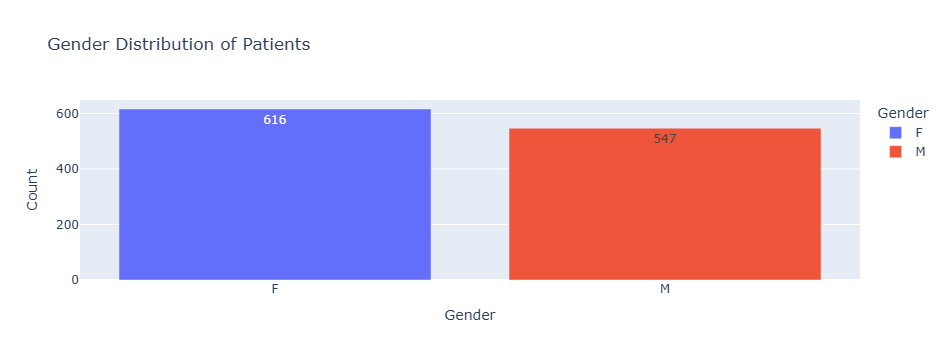

In [192]:
gender = patients['GENDER'].value_counts().reset_index()
gender.columns = ['Gender','Count']
fig = px.bar(
    gender,
    x='Gender',
    y='Count',
    title='Gender Distribution of Patients',
    color='Gender',
    text='Count'
)

fig.show()

Age Group Distribution:

The age group distribution indicates that Senior and Young Adult patients make up the largest proportion of the dataset. This suggests that these age groups are more strongly represented in the synthetic healthcare data, making them important populations for further analysis of healthcare expenses, medical conditions, and treatment patterns.

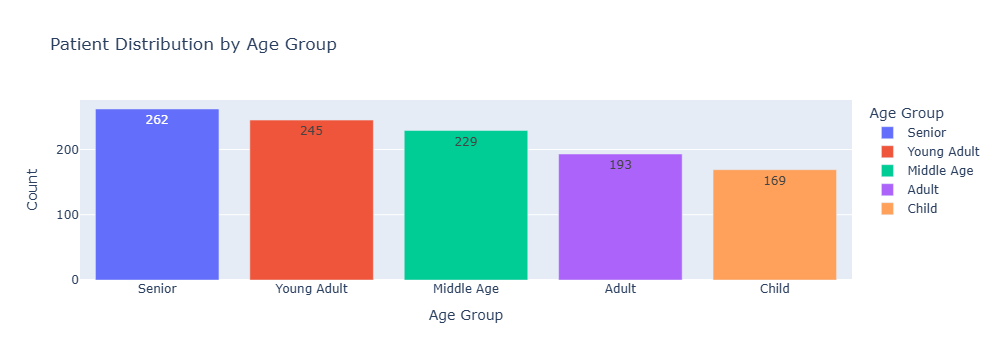

In [193]:
age_group = patients['Age_Group'].value_counts().reset_index()
age_group.columns = ['Age Group','Count']

fig = px.bar(
    age_group,
    x='Age Group',
    y='Count',
    title='Patient Distribution by Age Group',
    color='Age Group',
    text='Count'
)

fig.show()

Race Distribution:

The pie chart represents the proportion of patients from different racial groups. It helps visualize the demographic composition of the dataset and identifies the most represented race, supporting demographic analysis.

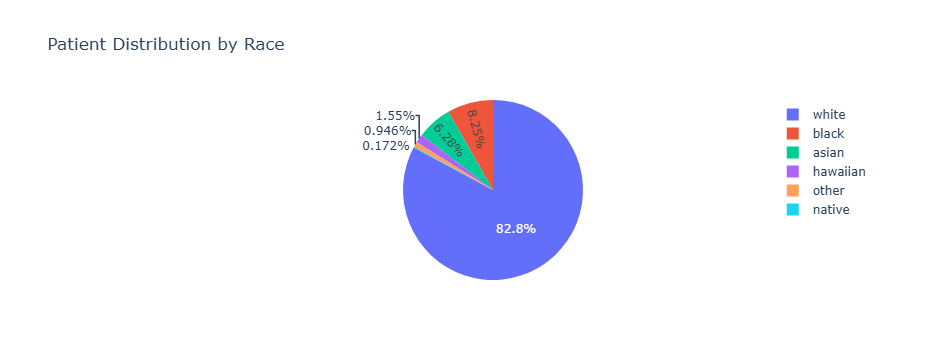

In [194]:
race = patients['RACE'].value_counts().reset_index()
race.columns = ['Race','Count']

fig = px.pie(
    race,
    names='Race',
    values='Count',
    title='Patient Distribution by Race'
)

fig.show()

Healthcare Expenses Distribution:

The histogram shows that most patients have relatively low healthcare expenses, while only a few patients have very high expenses. This indicates a right-skewed distribution with some high-cost outliers.


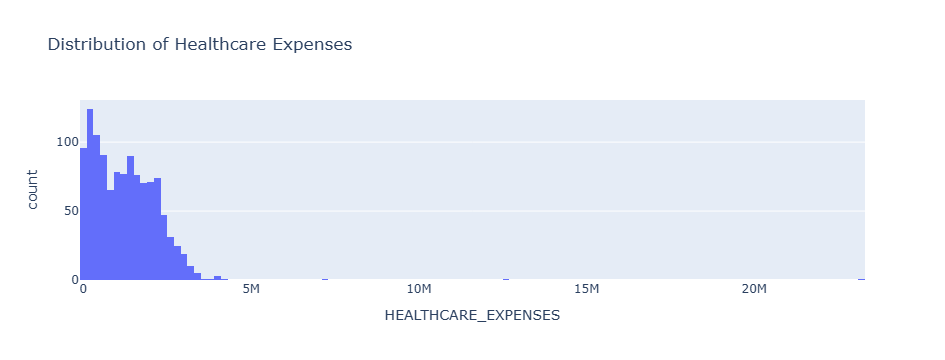

In [195]:
fig = px.histogram(
    patients,
    x='HEALTHCARE_EXPENSES',
    title='Distribution of Healthcare Expenses'
)

fig.show()

Healthcare Expenses by Gender:

The box plot compares healthcare expenses between male and female patients. Both genders show a wide variation in healthcare expenses, with several outliers. Female patients appear to have slightly higher healthcare expenses than male patients in this dataset.


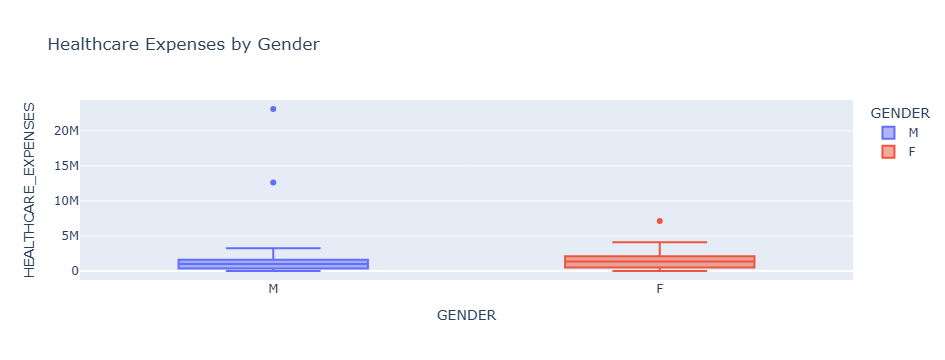

In [196]:
fig = px.box(
    patients,
    x='GENDER',
    y='HEALTHCARE_EXPENSES',
    color='GENDER',
    title='Healthcare Expenses by Gender'
)

fig.show()

Age vs Healthcare Expenses:

The scatter plot shows a positive relationship between age and healthcare expenses. As patient age increases, healthcare expenses generally tend to increase. However, a few younger patients also have high expenses, indicating that factors other than age also influence healthcare costs.


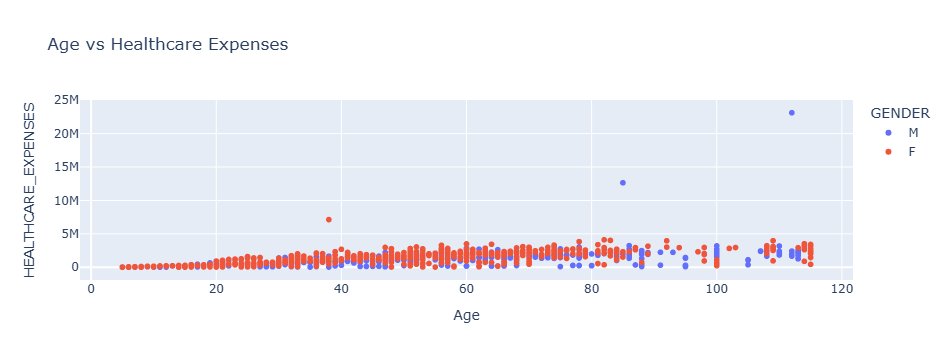

In [197]:
fig = px.scatter(
    patients,
    x='Age',
    y='HEALTHCARE_EXPENSES',
    color='GENDER',
    title='Age vs Healthcare Expenses'
)

fig.show()

Patient Visits by Year:

The line chart shows the trend of patient encounters over time. The number of patient visits gradually increases and rises sharply in the most recent years. This indicates higher healthcare utilization in the later years of the dataset
while only a few encounters are recorded in the early years because the synthetic dataset contains lifetime patient records.

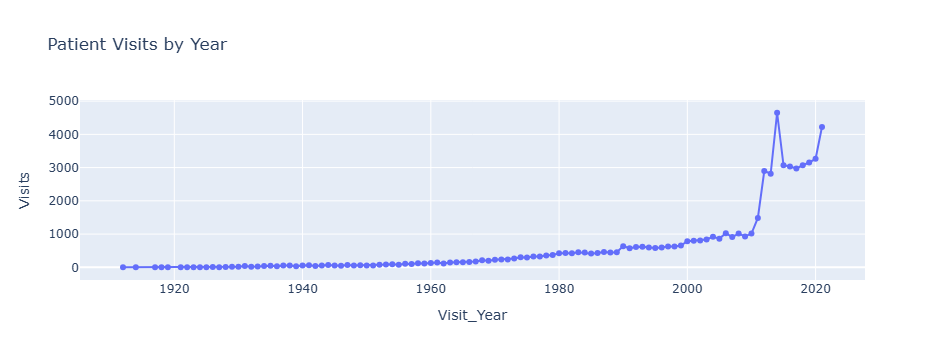

In [198]:
visit_year = encounters.groupby('Visit_Year').size().reset_index(name='Visits')
fig = px.line(
    visit_year,
    x='Visit_Year',
    y='Visits',
    title='Patient Visits by Year',
    markers=True
)

fig.show()

Top Diseases:

This chart identifies the ten most frequently recorded medical conditions. It highlights the most common diseases affecting patients, providing insight into prevalent health conditions within the dataset.

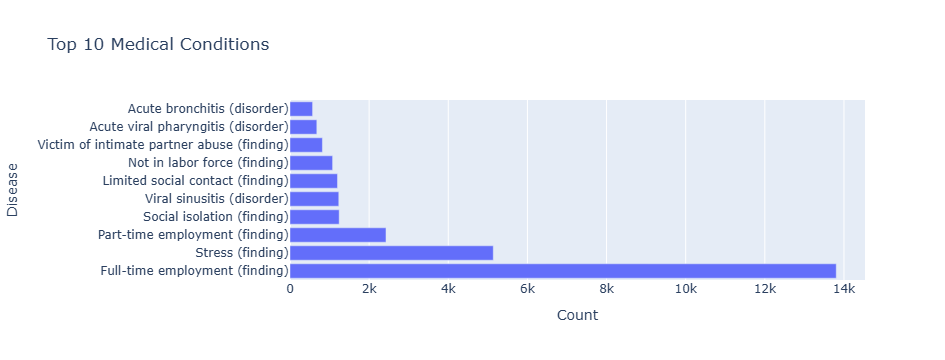

In [199]:
top_conditions = conditions['DESCRIPTION'].value_counts().head(10).reset_index()
top_conditions.columns=['Disease','Count']

fig = px.bar(
    top_conditions,
    x='Count',
    y='Disease',
    orientation='h',
    title='Top 10 Medical Conditions'
)

fig.show()

Top Medications:

The chart displays the ten most frequently prescribed medications. It helps identify common treatment patterns and the medications most often used for patient care.

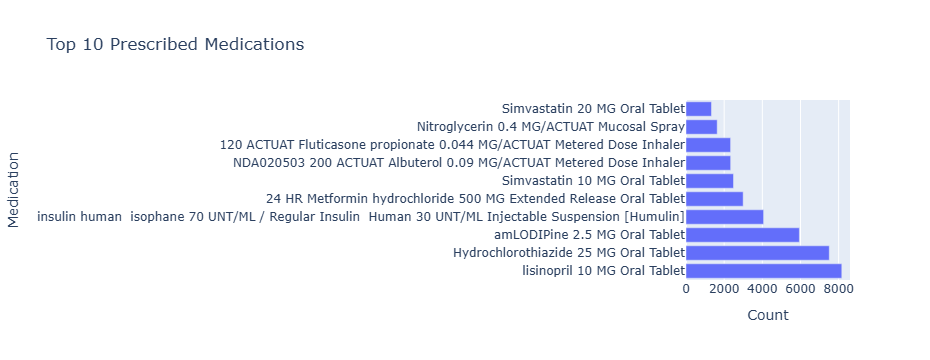

In [200]:
top_medications = medications['DESCRIPTION'].value_counts().head(10).reset_index()
top_medications.columns=['Medication','Count']

fig = px.bar(
    top_medications,
    x='Count',
    y='Medication',
    orientation='h',
    title='Top 10 Prescribed Medications'
)

fig.show()

Correlation Heatmap:

The correlation heatmap indicates a moderate positive correlation (0.594) between Age and Healthcare Expenses, suggesting that healthcare costs generally increase as patients become older. Age has a weaker positive relationship with Healthcare Coverage (0.321), while Healthcare Expenses and Healthcare Coverage show only a weak positive correlation (0.268), indicating that coverage alone does not fully explain variations in healthcare expenses.

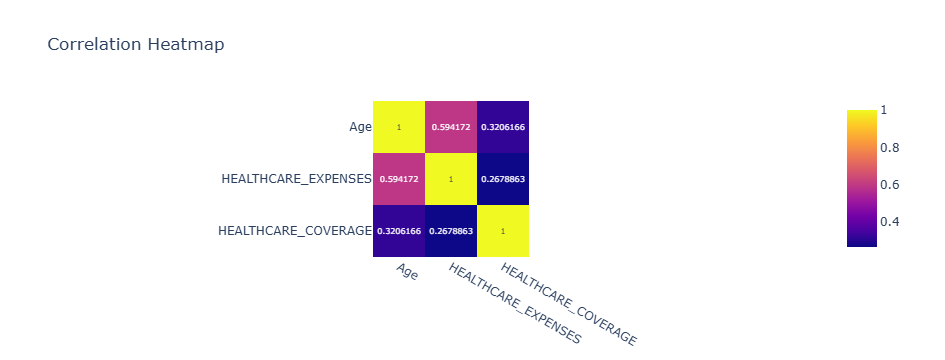

In [201]:
corr = patients[
    ['Age','HEALTHCARE_EXPENSES','HEALTHCARE_COVERAGE']
].corr()
fig = px.imshow(
    corr,
    text_auto=True,
    title='Correlation Heatmap'
)

fig.show()

Create Dashboard

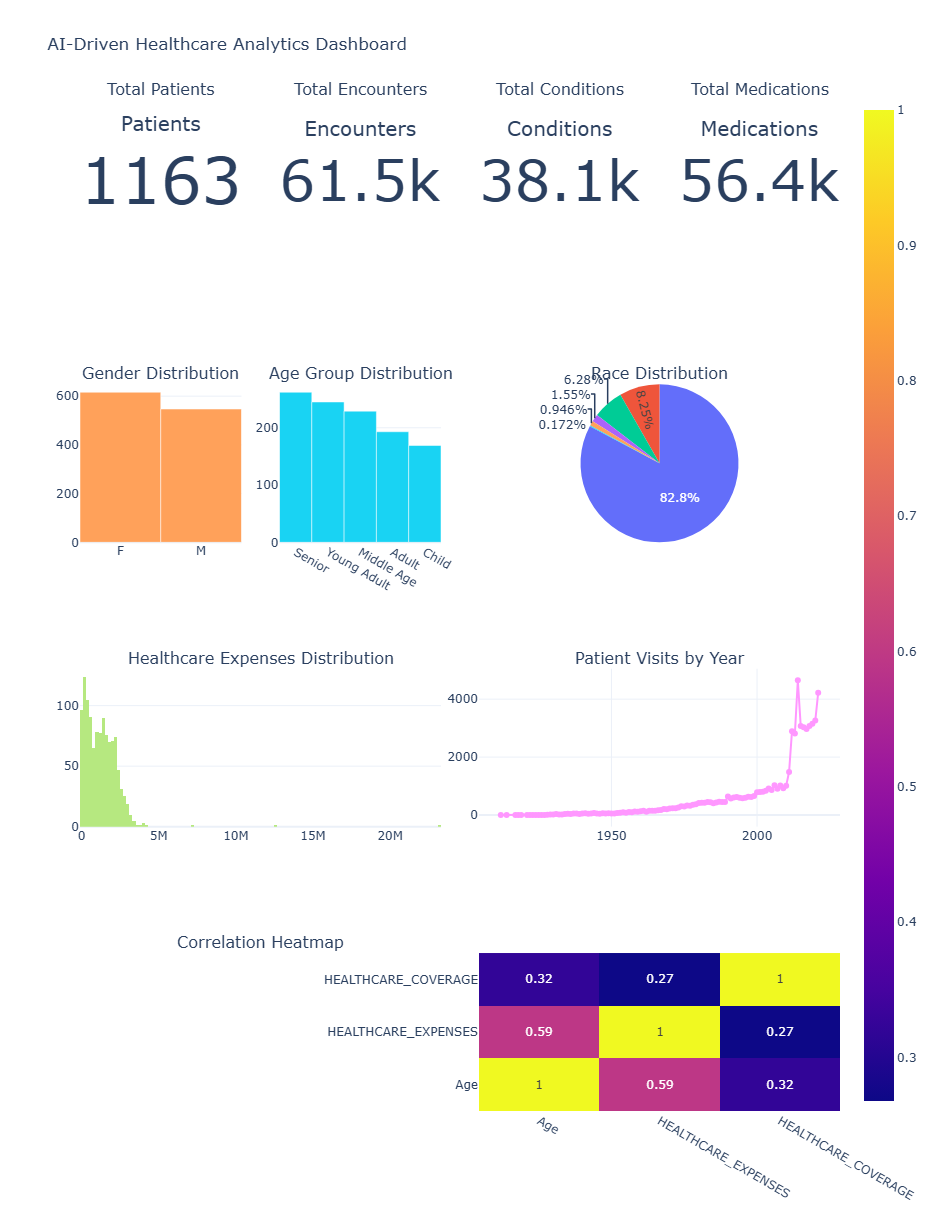

In [202]:

gender = patients['GENDER'].value_counts().reset_index()
gender.columns = ['Gender', 'Count']

age_group = patients['Age_Group'].value_counts().reset_index()
age_group.columns = ['Age Group', 'Count']

race = patients['RACE'].value_counts().reset_index()
race.columns = ['Race', 'Count']

visit_year = encounters.groupby('Visit_Year').size().reset_index(name='Visits')

corr = patients[['Age', 'HEALTHCARE_EXPENSES', 'HEALTHCARE_COVERAGE']].corr()

fig = make_subplots(
    rows=4,
    cols=4,

    specs=[
        [{"type":"indicator"},{"type":"indicator"},{"type":"indicator"},{"type":"indicator"}],
        [{"type":"bar"},{"type":"bar"},{"colspan":2,"type":"pie"},None],
        [{"colspan":2,"type":"xy"},None,{"colspan":2,"type":"xy"},None],
        [{"colspan":2,"type":"xy"},None,{"colspan":2,"type":"heatmap"},None]
    ],

    subplot_titles=(
        "Total Patients",
        "Total Encounters",
        "Total Conditions",
        "Total Medications",
        "Gender Distribution",
        "Age Group Distribution",
        "Race Distribution",
        "Healthcare Expenses Distribution",
        "Patient Visits by Year",
        "Correlation Heatmap"
    )
)

# KPIs
fig.add_trace(go.Indicator(mode="number",
                           value=len(patients),
                           title={"text":"Patients"}), row=1, col=1)

fig.add_trace(go.Indicator(mode="number",
                           value=len(encounters),
                           title={"text":"Encounters"}), row=1, col=2)

fig.add_trace(go.Indicator(mode="number",
                           value=len(conditions),
                           title={"text":"Conditions"}), row=1, col=3)

fig.add_trace(go.Indicator(mode="number",
                           value=len(medications),
                           title={"text":"Medications"}), row=1, col=4)

# Gender
fig.add_trace(
    go.Bar(x=gender['Gender'], y=gender['Count']),
    row=2, col=1
)

# Age Group
fig.add_trace(
    go.Bar(x=age_group['Age Group'], y=age_group['Count']),
    row=2, col=2
)

# Race
fig.add_trace(
    go.Pie(labels=race['Race'], values=race['Count']),
    row=2, col=3
)

# Expenses
fig.add_trace(
    go.Histogram(x=patients['HEALTHCARE_EXPENSES']),
    row=3, col=1
)

# Visits
fig.add_trace(
    go.Scatter(
        x=visit_year['Visit_Year'],
        y=visit_year['Visits'],
        mode='lines+markers'
    ),
    row=3, col=3
)

# Heatmap
fig.add_trace(
    go.Heatmap(
        z=corr.values,
        x=corr.columns,
        y=corr.columns,
        text=corr.round(2).values,
        texttemplate="%{text}"
    ),
    row=4, col=3
)

fig.update_layout(
    title="AI-Driven Healthcare Analytics Dashboard",
    height=1200,
    width=1500,
    template="plotly_white",
    showlegend=False
)

fig.show()

# AI Model – Patient Risk Assessment

The objective of this model is to classify patients into High Risk and Low Risk categories based on selected patient characteristics, including Age, Gender, Race, and Healthcare Coverage. A Random Forest Classifier was chosen because it is a reliable and widely used supervised machine learning algorithm for classification tasks. It is capable of learning patterns from historical data and making predictions for new observations.

The dataset was divided into training and testing sets to evaluate the model's performance. After training, the model was assessed using Accuracy Score, Confusion Matrix, and Classification Report. In addition, Feature Importance was analyzed to identify which patient characteristics contributed most to the prediction.

This AI model demonstrates how machine learning can support healthcare analytics by helping identify patients who may require additional monitoring and improved healthcare planning.

In [207]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import pandas as pd
import plotly.express as px


Accuracy: 0.8497854077253219
[[101  15]
 [ 20  97]]
              precision    recall  f1-score   support

           0       0.83      0.87      0.85       116
           1       0.87      0.83      0.85       117

    accuracy                           0.85       233
   macro avg       0.85      0.85      0.85       233
weighted avg       0.85      0.85      0.85       233



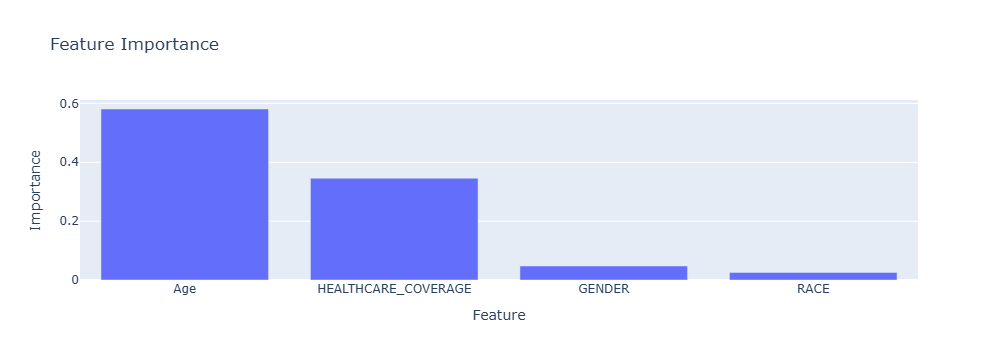

,Feature,Importance
0,Age,0.580900
3,HEALTHCARE_COVERAGE,0.345742
1,GENDER,0.047573
2,RACE,0.025785


In [213]:
patients['Risk_Level']=patients['HEALTHCARE_EXPENSES'].apply(lambda x:'High Risk' if x>patients['HEALTHCARE_EXPENSES'].median() else 'Low Risk')
ai_df=patients[['Age','GENDER','RACE','HEALTHCARE_COVERAGE','Risk_Level']].copy()
lg=LabelEncoder(); lr=LabelEncoder(); lt=LabelEncoder()
ai_df['GENDER']=lg.fit_transform(ai_df['GENDER'])
ai_df['RACE']=lr.fit_transform(ai_df['RACE'])
ai_df['Risk_Level']=lt.fit_transform(ai_df['Risk_Level'])
X=ai_df[['Age','GENDER','RACE','HEALTHCARE_COVERAGE']]
y=ai_df['Risk_Level']
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)
model=RandomForestClassifier(n_estimators=100,random_state=42)
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print('Accuracy:',accuracy_score(y_test,y_pred))
print(confusion_matrix(y_test,y_pred))
print(classification_report(y_test,y_pred))
importance=pd.DataFrame({'Feature':X.columns,'Importance':model.feature_importances_}).sort_values('Importance',ascending=False)
fig=px.bar(importance,x='Feature',y='Importance',title='Feature Importance')
fig.show()
importance


Accuracy Interpretation:

The Random Forest model achieved an accuracy of 84.98%, indicating that it correctly classified approximately 85% of the patients into High Risk and Low Risk categories. This suggests that the selected patient features were effective in predicting the defined risk level.

 Confusion Matrix Interpretation:

The confusion matrix shows that the model correctly identified 101 Low Risk patients and 97 High Risk patients. Only 35 out of 233 predictions were incorrect. This indicates that the model performs well in distinguishing between the two patient risk categories.

 Classification Report Interpretation:

The classification report shows balanced performance across both classes. The model achieved precision, recall, and F1-scores of approximately 0.85, indicating that it makes reliable predictions while correctly identifying most patients in each risk category.

 Feature Importance Interpretation:

The feature importance analysis indicates that Age is the most influential factor in predicting patient risk, contributing approximately 58% to the model's decision-making process. Healthcare Coverage is the second most important feature, contributing about 35%. In comparison, Gender and Race have relatively low importance, suggesting that they had less influence on the prediction. This indicates that patient age and healthcare coverage were the primary factors used by the model to classify patients into High Risk and Low Risk categories.

# AI Model Conclusion

The AI model was successfully trained using patient data and achieved an accuracy of approximately 85%. The results show that the model can effectively classify patients into High Risk and Low Risk categories. This demonstrates how machine learning can support healthcare data analysis by identifying important patient risk factors and assisting in decision-making.

# Key Insights

Based on the exploratory data analysis and visualizations, the following key insights were identified:

1. **Patient Demographics**

   * The dataset contains a balanced distribution of male and female patients, enabling meaningful comparisons across genders.
   * Senior and Young Adult patients represent the largest age groups in the dataset, making them important populations for further healthcare analysis.

2. **Healthcare Expenses**

   * Healthcare expenses are right-skewed, with most patients incurring relatively low costs while a small number of patients have significantly higher medical expenses.
   * Several high-cost outliers were identified, indicating that certain patients require substantially more healthcare resources.

3. **Medical Conditions and Medications**

   * A limited number of medical conditions account for a large proportion of patient diagnoses.
   * Similarly, a few medications are prescribed much more frequently than others, reflecting common treatment patterns within the dataset.

4. **Healthcare Utilization**

   * Patient encounters increased considerably in recent years, indicating greater healthcare utilization within the synthetic dataset.

5. **Relationship Between Variables**

   * Correlation analysis revealed a moderate positive relationship between patient age and healthcare expenses (correlation = 0.594), suggesting that healthcare costs generally increase with age.
   * Healthcare coverage showed only a weak positive relationship with healthcare expenses, indicating that additional factors influence overall medical costs.




# Significant Patterns and Anomalies

### Patterns Identified

* Healthcare expenses generally increase as patient age increases.
* Senior and Young Adult patients form the largest proportion of the dataset.
* Patient encounters show an increasing trend over recent years.
* A small number of diseases and medications account for a significant share of healthcare activity.
* Age and healthcare coverage are the strongest predictors of patient risk in the AI model.

### Anomalies Observed

* Several patients exhibit exceptionally high healthcare expenses compared to the majority of the population. These observations appear as outliers in the box plot and histogram.
* Some younger patients also have relatively high healthcare expenses, indicating that age alone does not determine healthcare costs.
* Historical encounter records from the early 1900s contain very few observations because the Synthea dataset simulates complete patient lifetimes.
* Several columns contain a large number of missing values (such as DEATHDATE, STOP, and REASONDESCRIPTION). However, these are expected missing values because they depend on patient status (living patients do not have a death date, and active conditions do not have a stop date), so they were retained instead of being treated as data quality issues.


### Recommendations

* Healthcare providers should give additional attention to **high-risk and elderly patients**, as they tend to have higher healthcare expenses.
* Patients with chronic or active medical conditions should be monitored regularly to improve treatment outcomes.
* Healthcare organizations should use **data analytics dashboards** to monitor patient trends, healthcare costs, and resource utilization.
* Machine learning models can be used to identify high-risk patients early, allowing timely intervention and better healthcare planning.
* Regular analysis of healthcare data can help hospitals improve operational efficiency and support evidence-based decision-making.

### Future Scope

* The project can be enhanced by using **real-world healthcare datasets** to improve the accuracy and practical applicability of the analysis.
* More patient attributes, such as medical history, laboratory results, lifestyle factors, and vital signs, can be included to build more accurate predictive models.
* Additional machine learning algorithms, such as **Logistic Regression, Decision Tree, XGBoost, or Gradient Boosting**, can be compared with Random Forest to identify the best-performing model.
* The project can be integrated with an **interactive Power BI or Streamlit dashboard** to enable real-time healthcare monitoring and visualization.
* Future work can focus on predicting specific healthcare outcomes, such as **hospital readmission, disease progression, or treatment costs**, to support clinical decision-making.





# Conclusion

This project successfully analyzed a synthetic healthcare dataset using Python, Pandas, NumPy, Plotly, and Machine Learning techniques. The data was cleaned and preprocessed to ensure quality before performing exploratory data analysis to identify important patterns and trends. Various visualizations were created to understand patient demographics, healthcare expenses, medical conditions, medication costs, and healthcare utilization. A Random Forest Classifier was then developed to classify patients into High Risk and Low Risk categories, achieving an accuracy of approximately 85%. The results showed that Age and Healthcare Coverage were the most important factors influencing patient risk. Overall, this project demonstrates how data analytics and artificial intelligence can be used together to generate meaningful healthcare insights, support patient risk assessment, and assist in data-driven decision-making.